Generación 100: mejor distancia = 435.738
Generación 200: mejor distancia = 435.738
Generación 300: mejor distancia = 435.738
Generación 400: mejor distancia = 435.738

Mejor ruta encontrada:
G -> H -> F -> E -> A -> C -> B -> D -> G
Distancia total: 435.738


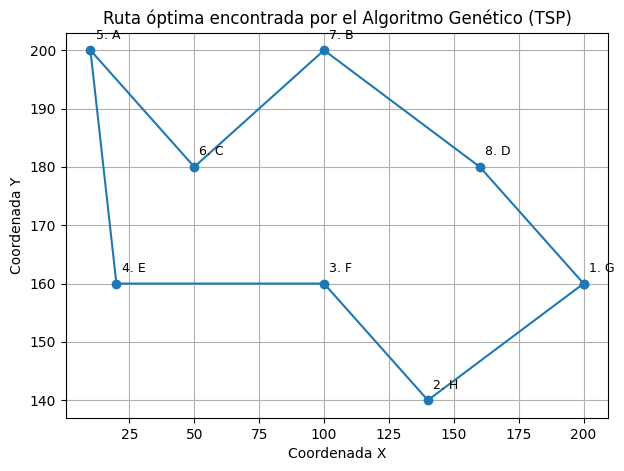

In [ ]:
# ===========================================================
# PROBLEMA DEL VIAJERO (TSP) RESUELTO CON ALGORITMO GENÉTICO
# ===========================================================

import random
import math
import matplotlib.pyplot as plt

# Fijamos una semilla para reproducibilidad (los mismos resultados cada ejecución)
random.seed(42)


# 1. DEFINICIÓN DE LAS CIUDADES Y SUS COORDENADAS

ciudades = {
    'A': (10, 200),
    'B': (100, 200),
    'C': (50, 180),
    'D': (160, 180),
    'E': (20, 160),
    'F': (100, 160),
    'G': (200, 160),
    'H': (140, 140)
}

# Obtenemos las listas de nombres y coordenadas
nombres = list(ciudades.keys())
coords = [ciudades[n] for n in nombres]


# 2. FUNCIONES AUXILIARES DE DISTANCIA Y FITNESS


def distancia(a, b):
    #Calcula la distancia euclidiana entre dos puntos.
    return math.hypot(a[0] - b[0], a[1] - b[1])

def distancia_total(ruta):
    #Suma la distancia total recorrida en una ruta cerrada.
    total = 0
    for i in range(len(ruta)):
        a = coords[ruta[i]]
        b = coords[ruta[(i + 1) % len(ruta)]]  # % para volver al inicio
        total += distancia(a, b)
    return total

def fitness(individuo):
    #Evalúa qué tan buena es una ruta.
    #Cuanto menor sea la distancia, mayor será el fitness.
    return 1 / (distancia_total(individuo) + 1e-9)


# 3. CREACIÓN DE LA POBLACIÓN INICIAL


def crear_poblacion(tamaño, num_ciudades):


    #Crea la población inicial aleatoria.
    #Cada individuo es una permutación de los índices de las ciudades.

    base = list(range(num_ciudades))
    return [random.sample(base, len(base)) for _ in range(tamaño)]


# 4. OPERADORES GENÉTICOS (SELECCIÓN, CRUCE Y MUTACIÓN)


def seleccion_torneo(poblacion, k=5):


    #SELECCIÓN POR TORNEO:
    #- Escoge aleatoriamente k individuos de la población.
    #- De esos k, el que tenga mejor fitness 'gana' y se selecciona como padre.

    candidatos = random.sample(poblacion, k)
    return max(candidatos, key=fitness)

def crossover(p1, p2):

    #CRUCE ORDENADO (Ordered Crossover - OX):
    #- Selecciona un segmento del primer padre (p1).
    #- Rellena los huecos con las ciudades del segundo padre (p2),
    # respetando el orden en que aparecen y sin repetir ninguna ciudad.

    size = len(p1)
    a, b = sorted(random.sample(range(size), 2))  # puntos de corte
    hijo = [-1] * size  # hijo vacío (usamos -1 como marcador)

    # Copiamos el segmento del primer padre
    hijo[a:b+1] = p1[a:b+1]

    # Rellenamos el resto con genes del segundo padre
    pos = (b + 1) % size
    p2pos = (b + 1) % size
    while -1 in hijo:
        gene = p2[p2pos]
        if gene not in hijo:
            hijo[pos] = gene
            pos = (pos + 1) % size
        p2pos = (p2pos + 1) % size
    return hijo

def mutacion_swap(individuo, tasa=0.12):


    #MUTACIÓN POR INTERCAMBIO:
    #- Con una cierta probabilidad (tasa),
    #  intercambiamos dos ciudades de lugar dentro del individuo.
    #- Esto ayuda a mantener diversidad genética y evitar convergencia prematura.

    ind = individuo[:]
    if random.random() < tasa:
        i, j = random.sample(range(len(ind)), 2)
        ind[i], ind[j] = ind[j], ind[i]
    return ind

# -----------------------------------------------------------
# 5. PROCESO DE EVOLUCIÓN (CICLO GENÉTICO)
# -----------------------------------------------------------

def evolucionar(poblacion, elitismo=True):

    #Realiza una generación del algoritmo genético:
    #- Selecciona padres usando torneo.
    #- Aplica crossover y mutación para generar hijos.
    #- Conserva al mejor individuo si elitismo=True.

    Elitismo: asegura que el mejor individuo no se pierda en la siguiente generación.

    nueva = []

    # Guardamos el mejor individuo (elitismo)
    if elitismo:
        elite = max(poblacion, key=fitness)
        nueva.append(elite)

    # Creamos el resto de la nueva generación
    while len(nueva) < len(poblacion):
        # 1. Selección de padres
        p1 = seleccion_torneo(poblacion)
        p2 = seleccion_torneo(poblacion)

        # 2. Cruce
        hijo = crossover(p1, p2)

        # 3. Mutación
        hijo = mutacion_swap(hijo)

        # 4. Añadir hijo a la nueva población
        nueva.append(hijo)

    # Retorna la nueva generación (misma cantidad de individuos)
    return nueva[:len(poblacion)]


# 6. PARÁMETROS DEL ALGORITMO GENÉTICO


POBLACION = 150      # Tamaño de la población
GENERACIONES = 400   # Número de generaciones (iteraciones)
ciudades_totales = len(ciudades)


# 7. EJECUCIÓN DEL ALGORITMO GENÉTICO


poblacion = crear_poblacion(POBLACION, ciudades_totales)
hist_mejor = []  # Guardará la mejor distancia de cada generación

for gen in range(GENERACIONES):
    poblacion = evolucionar(poblacion)  # Evolucionamos una generación
    mejor = min(poblacion, key=distancia_total)  # Mejor individuo actual
    mejor_dist = distancia_total(mejor)
    hist_mejor.append(mejor_dist)

    # Mostramos progreso cada 100 generaciones
    if (gen + 1) % 100 == 0:
        print(f"Generación {gen+1}: mejor distancia = {mejor_dist:.3f}")


# 8. RESULTADOS FINALES


mejor_ruta = min(poblacion, key=distancia_total)
mejor_distancia = distancia_total(mejor_ruta)
mejor_ruta_nombres = [nombres[i] for i in mejor_ruta]

print("\nMejor ruta encontrada:")
print(" -> ".join(mejor_ruta_nombres) + f" -> {mejor_ruta_nombres[0]}")
print(f"Distancia total: {mejor_distancia:.3f}")


# 9. VISUALIZACIÓN DE LA MEJOR RUTA


# Preparamos coordenadas para graficar
xs = [coords[i][0] for i in mejor_ruta] + [coords[mejor_ruta[0]][0]]
ys = [coords[i][1] for i in mejor_ruta] + [coords[mejor_ruta[0]][1]]

# Dibujamos la ruta óptima encontrada
plt.figure(figsize=(7, 5))
plt.plot(xs, ys, marker='o', linestyle='-')
for i, idx in enumerate(mejor_ruta):
    plt.text(coords[idx][0]+2, coords[idx][1]+2, f"{i+1}. {nombres[idx]}", fontsize=9)
plt.title("Ruta óptima encontrada por el Algoritmo Genético (TSP)")
plt.xlabel("Coordenada X")
plt.ylabel("Coordenada Y")
plt.grid(True)
plt.show()
